# 06. ELECTRE TRI-B q·p 보정과 시간 외 검증
v1.0을 보존한 채 사전 명시된 A–D 후보를 보정구간(2022Q1–2024Q4)에서 비교하고, 선택 후 holdout(2025Q1–2026Q2)을 확인한다. 이후 상태와의 관계는 방향적 정합성이며 예측 정확도나 인과효과가 아니다.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
from model import manifest, params
qp_runs=sorted((ROOT/'outputs/qp_runs').glob('*/qp_run_manifest.json'),key=lambda p:p.stat().st_mtime)
qp_manifest=json.loads(qp_runs[-1].read_text(encoding='utf-8'))
def table(name):
    d=pd.read_csv(ROOT/qp_manifest['files'][name]['canonical_path'])
    assert set(d.run_id.astype(str))=={qp_manifest['run_id']}
    return d


## 1. 사전 감사와 v1.0 재현
g1은 명, g2·g3는 퍼센트포인트, g4는 분기 단위다. 모든 기준은 증가 방향이다. v1.0 해시는 등록값과 일치하며 crisp 분포 86/41/33/20, 단순규칙 일치 157/160, 불일치 3건, 단조성·dominance 위반 0건을 재현한 뒤 후보 실행을 시작했다.

In [2]:
registry=table('electre_qp_candidate_registry')
comparison=table('electre_qp_candidate_comparison')
decision=table('electre_qp_selection_decision')
display(registry[['candidate_id','criterion','q_input','p_input','input_unit','unit_conversion_factor','selected_on_calibration']])
display(comparison[comparison.scenario_id=='기준'])
display(decision)


,candidate_id,criterion,q_input,p_input,input_unit,unit_conversion_factor,selected_on_calibration
0,v1.0_crisp,g1,0.00,0.0,persons,1.0,False
1,v1.0_crisp,g2,0.00,0.0,percentage_points,1.0,False
2,v1.0_crisp,g3,0.00,0.0,percentage_points,1.0,False
3,v1.0_crisp,g4,0.00,0.0,quarters,1.0,False
4,A_narrow,g1,0.00,50.0,persons,1.0,False
5,A_narrow,g2,0.00,0.5,percentage_points,1.0,False
6,A_narrow,g3,0.00,1.0,percentage_points,1.0,False
7,A_narrow,g4,0.00,1.0,quarters,1.0,False
8,B_medium,g1,0.00,100.0,persons,1.0,False
9,B_medium,g2,0.00,1.0,percentage_points,1.0,False


,candidate_id,scenario_id,constraints_passed,range_violations,boundary_contradictions,monotonicity_violations,dominance_violations,row_order_independent,passed,n_observe,...,external_alignment_mean,p_total,selection_uses_holdout,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,v1.0_crisp,기준,True,0,0,0,0,True,True,86,...,-0.039824,0.0,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
3,A_narrow,기준,True,0,0,0,0,True,True,86,...,-0.046771,52.5,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
6,B_medium,기준,True,0,0,0,0,True,True,81,...,-0.016038,105.0,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
9,C_wide,기준,True,0,0,0,0,True,True,77,...,-0.020161,156.5,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
12,D_small_indifference,기준,True,0,0,0,0,True,True,79,...,-0.014008,105.0,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...


,selected_on_calibration,final_decision,holdout_used_for_selection,holdout_improvement_test_count,external_alignment_improved,external_direction_supported,holdout_ordered_next_negative,minimum_p_perturbation_retention,leave_one_industry_selection_retention,calibration_period,...,candidate_file_created,adoption_status,reason,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,D_small_indifference,INSUFFICIENT_EVIDENCE,False,2,True,False,False,0.96875,0.9,2022Q1-2024Q4,...,False,NO_QP_CANDIDATE_ADOPTED,일부 holdout 지표는 개선됐으나 단계 순서와 양의 외적 정합성이 입증되지 않아...,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...


## 2. 후보별 분류와 부분 concordance
가중치·lambda·b1·b2는 고정하고 q·p만 비교했다. 품질 플래그와 보조지표는 concordance에 포함하지 않았다.

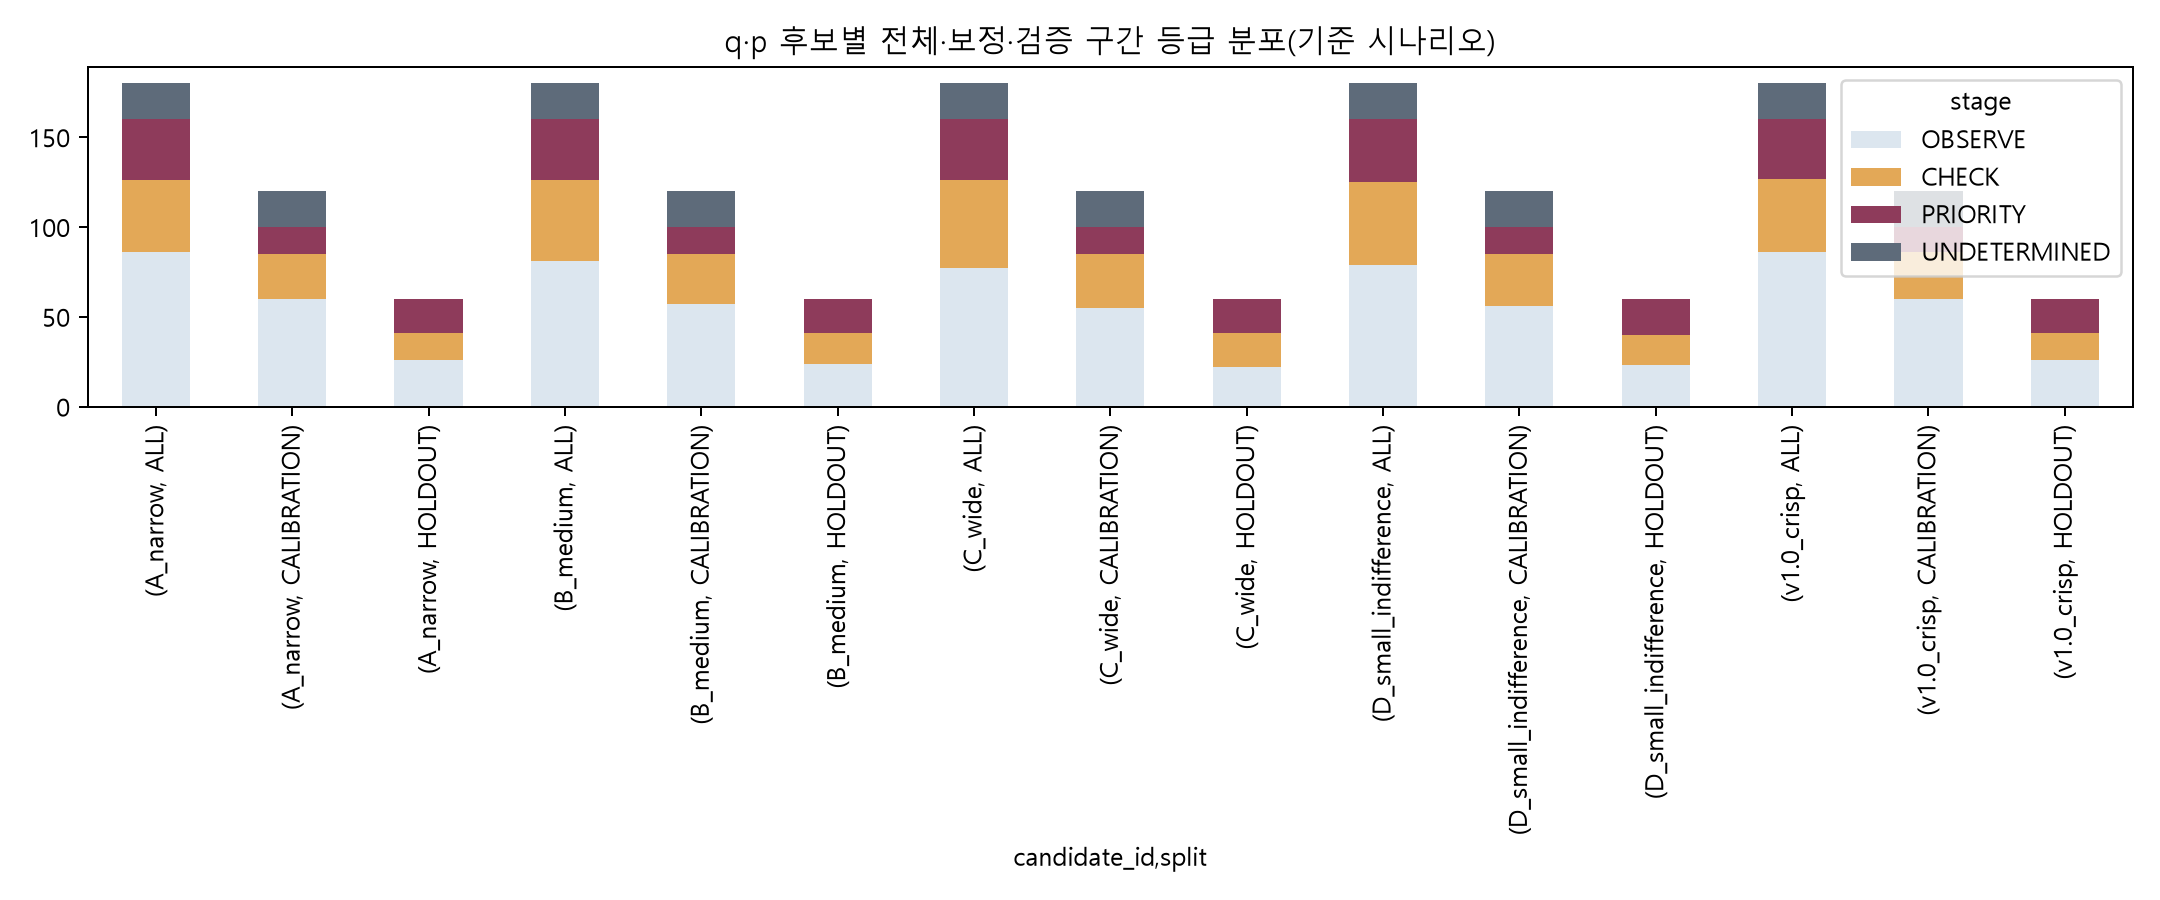

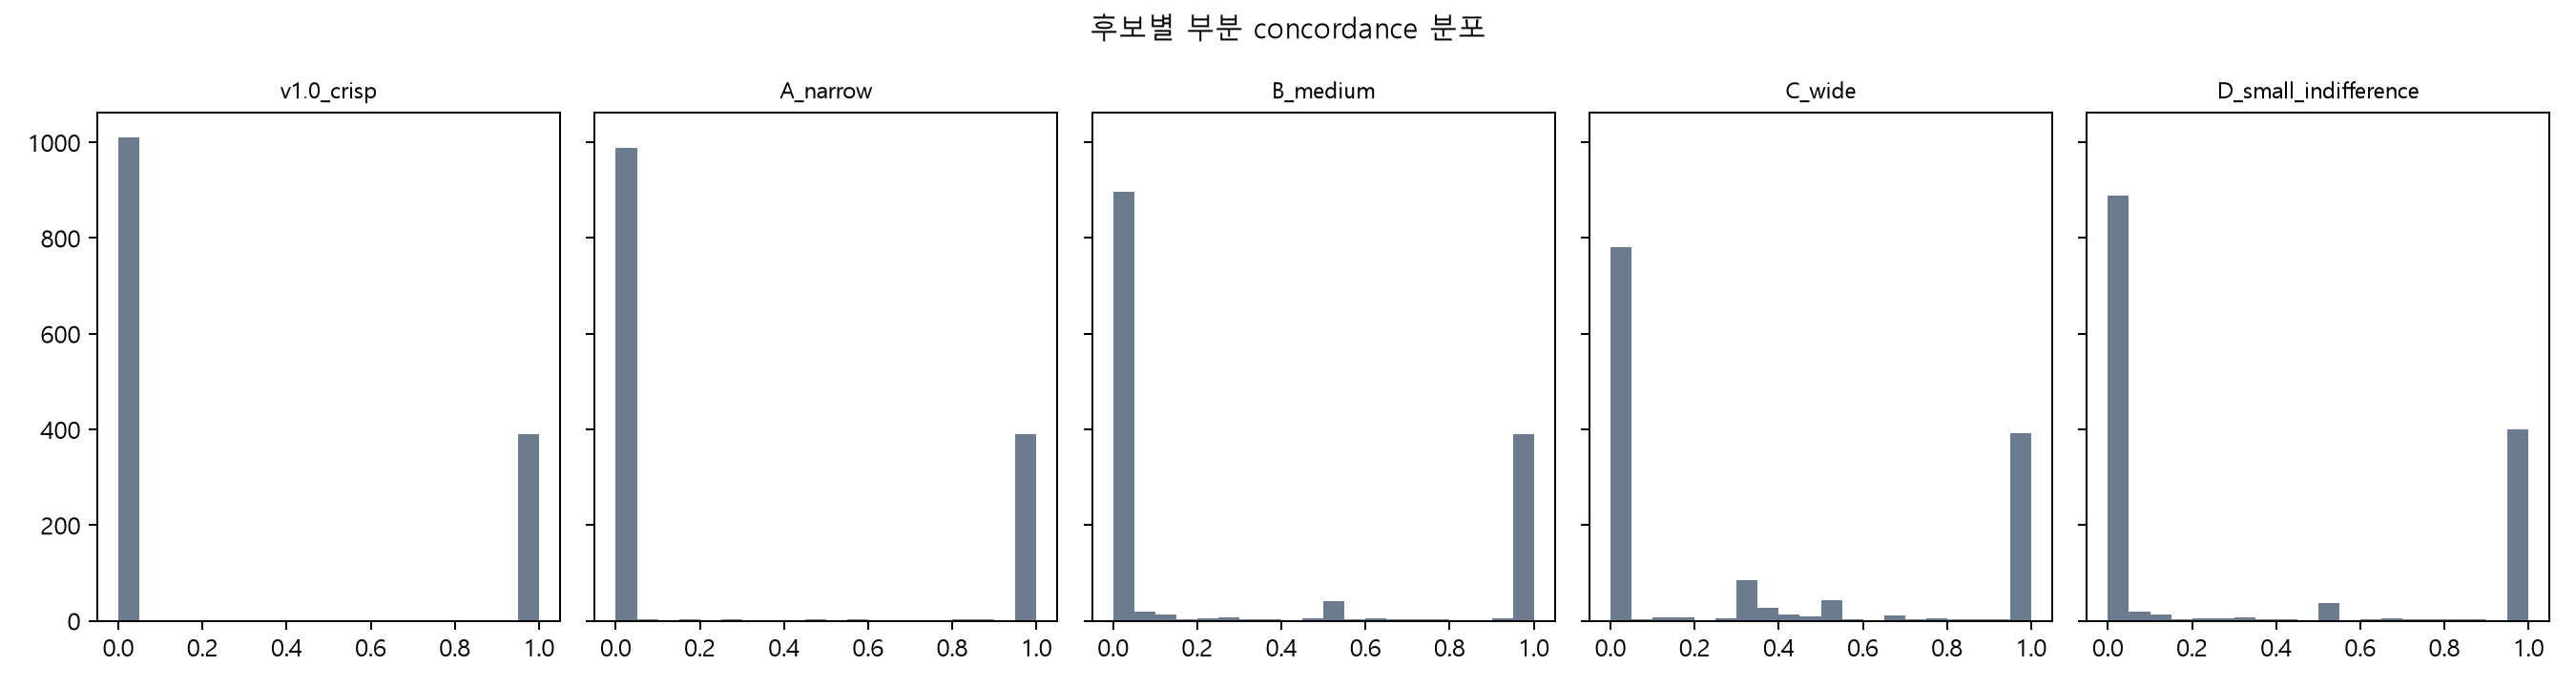

g1_c  g2_c  g3_c  g4_c
candidate_id         boundary                        
A_narrow             b1          30    18     6     0
                     b2           0     9    15     0
B_medium             b1         186    39    15    60
                     b2           6    12    21    42
C_wide               b1         429    66    24    60
                     b2          18    33    27    42
D_small_indifference b1         180    33     9    60
                     b2           6    12    15    42
v1.0_crisp           b1           0     0     0     0
                     b2           0     0     0     0

In [3]:
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_candidate_stage_distribution.png')))
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_partial_concordance_distribution.png')))
trace=table('electre_qp_partial_concordance_trace')
display(trace.groupby(['candidate_id','boundary'])[[f'{g}_c' for g in ['g1','g2','g3','g4']]].agg(lambda x: ((x>0)&(x<1)).sum()))


## 3. 보정구간과 시간 외 검증

,candidate_id,scenario_id,stage,stage_rank,n_rows,next_negative_state_numerator,next_negative_state_denominator,next_negative_state_rate,next_employment_decline_numerator,next_employment_decline_denominator,...,t2_negative_state_denominator,t2_negative_state_rate,split,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,v1.0_crisp,기준,OBSERVE,0,48,10,48,0.208333,10,48,...,36,0.333333,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
1,v1.0_crisp,기준,CHECK,1,23,19,23,0.826087,19,23,...,19,0.684211,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
2,v1.0_crisp,기준,PRIORITY,2,9,9,9,1.000000,9,9,...,5,1.000000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
9,A_narrow,기준,OBSERVE,0,48,10,48,0.208333,10,48,...,36,0.333333,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
10,A_narrow,기준,CHECK,1,23,19,23,0.826087,19,23,...,19,0.684211,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
11,A_narrow,기준,PRIORITY,2,9,9,9,1.000000,9,9,...,5,1.000000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
18,B_medium,기준,OBSERVE,0,45,7,45,0.155556,7,45,...,33,0.272727,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
19,B_medium,기준,CHECK,1,26,22,26,0.846154,22,26,...,22,0.727273,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
20,B_medium,기준,PRIORITY,2,9,9,9,1.000000,9,9,...,5,1.000000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
27,C_wide,기준,OBSERVE,0,44,6,44,0.136364,6,44,...,32,0.250000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,a

,candidate_id,scenario_id,stage,stage_rank,n_rows,next_negative_state_numerator,next_negative_state_denominator,next_negative_state_rate,next_employment_decline_numerator,next_employment_decline_denominator,...,t2_negative_state_denominator,t2_negative_state_rate,split,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,v1.0_crisp,기준,OBSERVE,0,22,10,22,0.454545,10,22,...,18,0.666667,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
1,v1.0_crisp,기준,CHECK,1,11,11,11,1.000000,11,11,...,7,0.714286,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
2,v1.0_crisp,기준,PRIORITY,2,17,14,17,0.823529,14,17,...,15,0.733333,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
9,A_narrow,기준,OBSERVE,0,22,10,22,0.454545,10,22,...,18,0.666667,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
10,A_narrow,기준,CHECK,1,11,11,11,1.000000,11,11,...,7,0.714286,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
11,A_narrow,기준,PRIORITY,2,17,14,17,0.823529,14,17,...,15,0.733333,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
18,B_medium,기준,OBSERVE,0,20,8,20,0.400000,8,20,...,16,0.625000,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
19,B_medium,기준,CHECK,1,13,13,13,1.000000,13,13,...,9,0.777778,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
20,B_medium,기준,PRIORITY,2,17,14,17,0.823529,14,17,...,15,0.733333,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
27,C_wide,기준,OBSERVE,0,18,7,18,0.388889,7,18,...,16,0.625000,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069

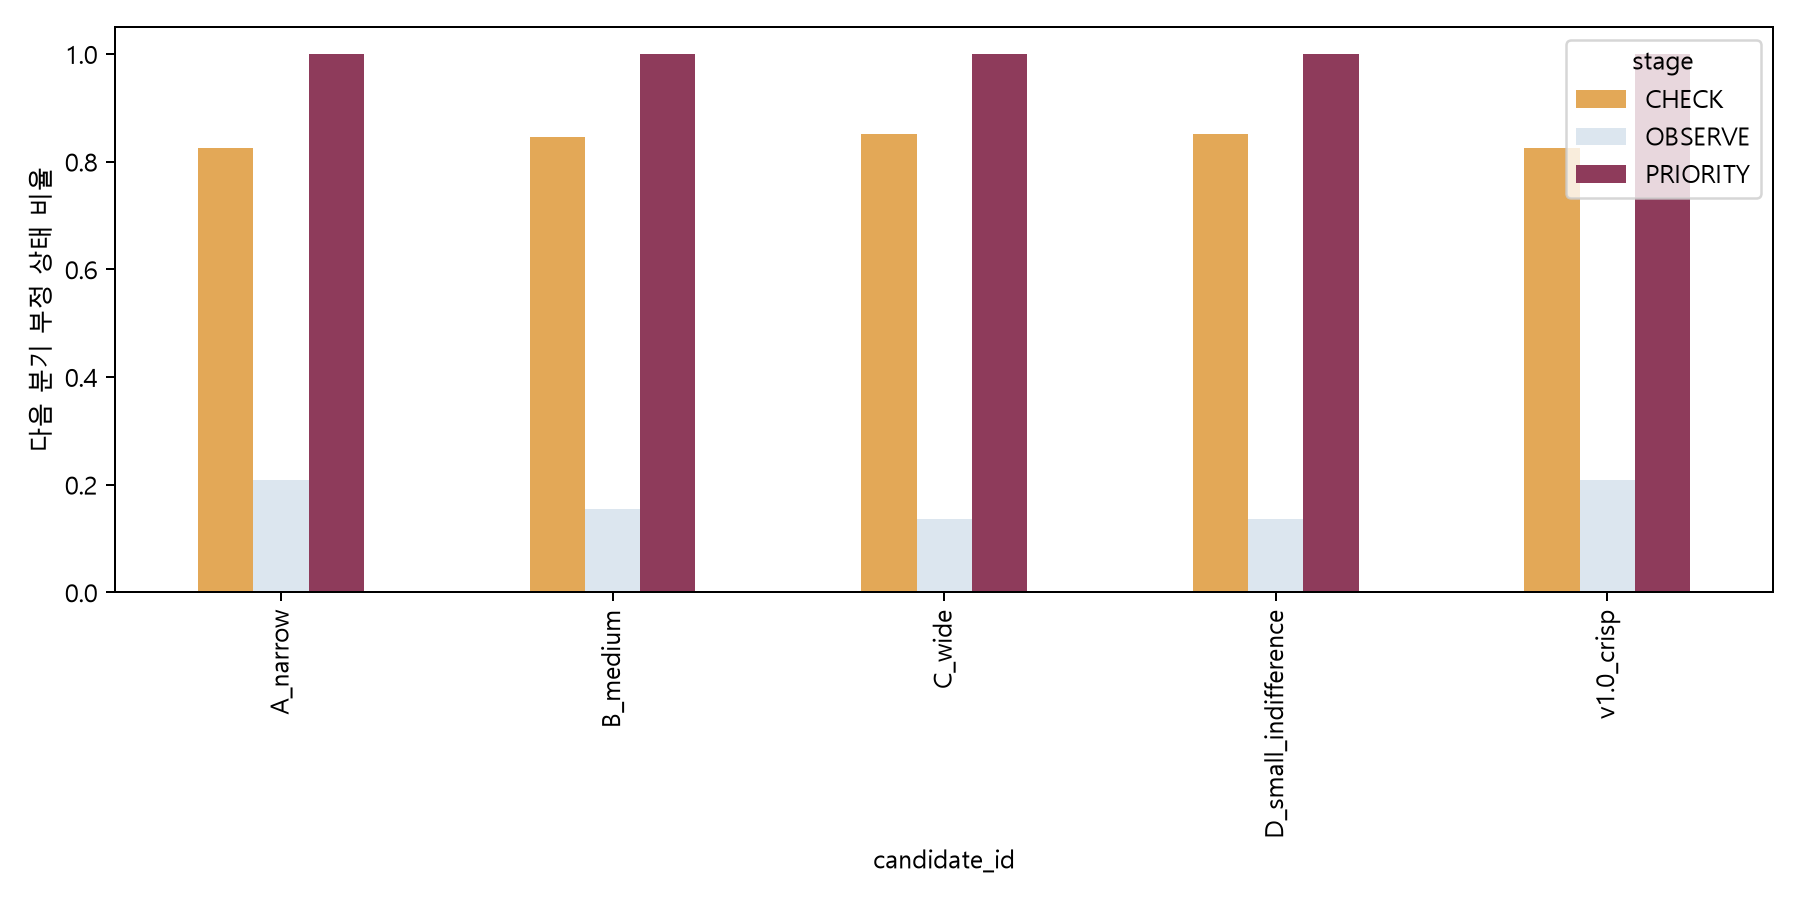

In [4]:
cal=table('electre_qp_calibration_results')
hold=table('electre_qp_holdout_validation')
display(cal[cal.scenario_id=='기준'])
display(hold[hold.scenario_id=='기준'])
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_next_negative_rates.png')))


## 4. 외적 정합성과 기존 불일치 3건
가동률·업체 수·PPI는 외적 확인에만 사용한다. 기계 2022Q1, 운송장비·전기전자 2025Q1은 진단 사례로만 추적하며 후보 설정 목표로 사용하지 않았다.

,candidate_id,scenario_id,stage,metric,status,numerator,denominator,rate,split,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,v1.0_crisp,기준,OBSERVE,operating_rate_worsened,EVALUATED,25,46,0.543478,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
1,v1.0_crisp,기준,OBSERVE,firm_count_declined,EVALUATED,21,60,0.350000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
2,v1.0_crisp,기준,OBSERVE,ppi_direction_stable,EVALUATED,44,60,0.733333,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
3,v1.0_crisp,기준,CHECK,operating_rate_worsened,EVALUATED,6,24,0.250000,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
4,v1.0_crisp,기준,CHECK,firm_count_declined,EVALUATED,9,26,0.346154,CALIBRATION,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,D_small_indifference,기준,CHECK,firm_count_declined,EVALUATED,3,17,0.176471,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
248,D_small_indifference,기준,CHECK,ppi_direction_stable,EVALUATED,12,17,0.705882,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
249,D_small_indifference,기준,PRIORITY,operating_rate_worsened,EVALUATED,9,17,0.529412,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
250,D_small_indifference,기준,PRIORITY,firm_count_declined,EVALUATED,4,20,0.200000,HOLDOUT,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...


,candidate_id,industry,quarter,boundary,stage,concordance,next_state,state_t2,g1_c,g2_c,g3_c,g4_c,op_rate_used_yoy_pp,firm_count_delta_yoy
0,v1.0_crisp,기계,2022Q1,b1,OBSERVE,0.4,S2,S2,1.0,1.0,0.0,0.0,1.262585,-18.0
1,v1.0_crisp,기계,2022Q1,b2,OBSERVE,0.2,S2,S2,1.0,0.0,0.0,0.0,1.262585,-18.0
240,v1.0_crisp,운송장비,2025Q1,b1,OBSERVE,0.4,S4,S2,1.0,1.0,0.0,0.0,NaN,3.0
241,v1.0_crisp,운송장비,2025Q1,b2,OBSERVE,0.0,S4,S2,0.0,0.0,0.0,0.0,NaN,3.0
312,v1.0_crisp,전기전자,2025Q1,b1,OBSERVE,0.4,S4,S4,1.0,1.0,0.0,0.0,NaN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5041,D_small_indifference,기계,2022Q1,b2,CHECK,0.2,S2,S2,1.0,0.0,0.0,0.0,1.262585,-18.0
5280,D_small_indifference,운송장비,2025Q1,b1,CHECK,0.6,S4,S2,1.0,1.0,0.0,0.5,NaN,3.0
5281,D_small_indifference,운송장비,2025Q1,b2,CHECK,0.0,S4,S2,0.0,0.0,0.0,0.0,NaN,3.0
5352,D_small_indifference,전기전자,2025Q1,b1,CHECK,0.6,S4,S4,1.0,1.0,0.0,0.5,NaN,17.0


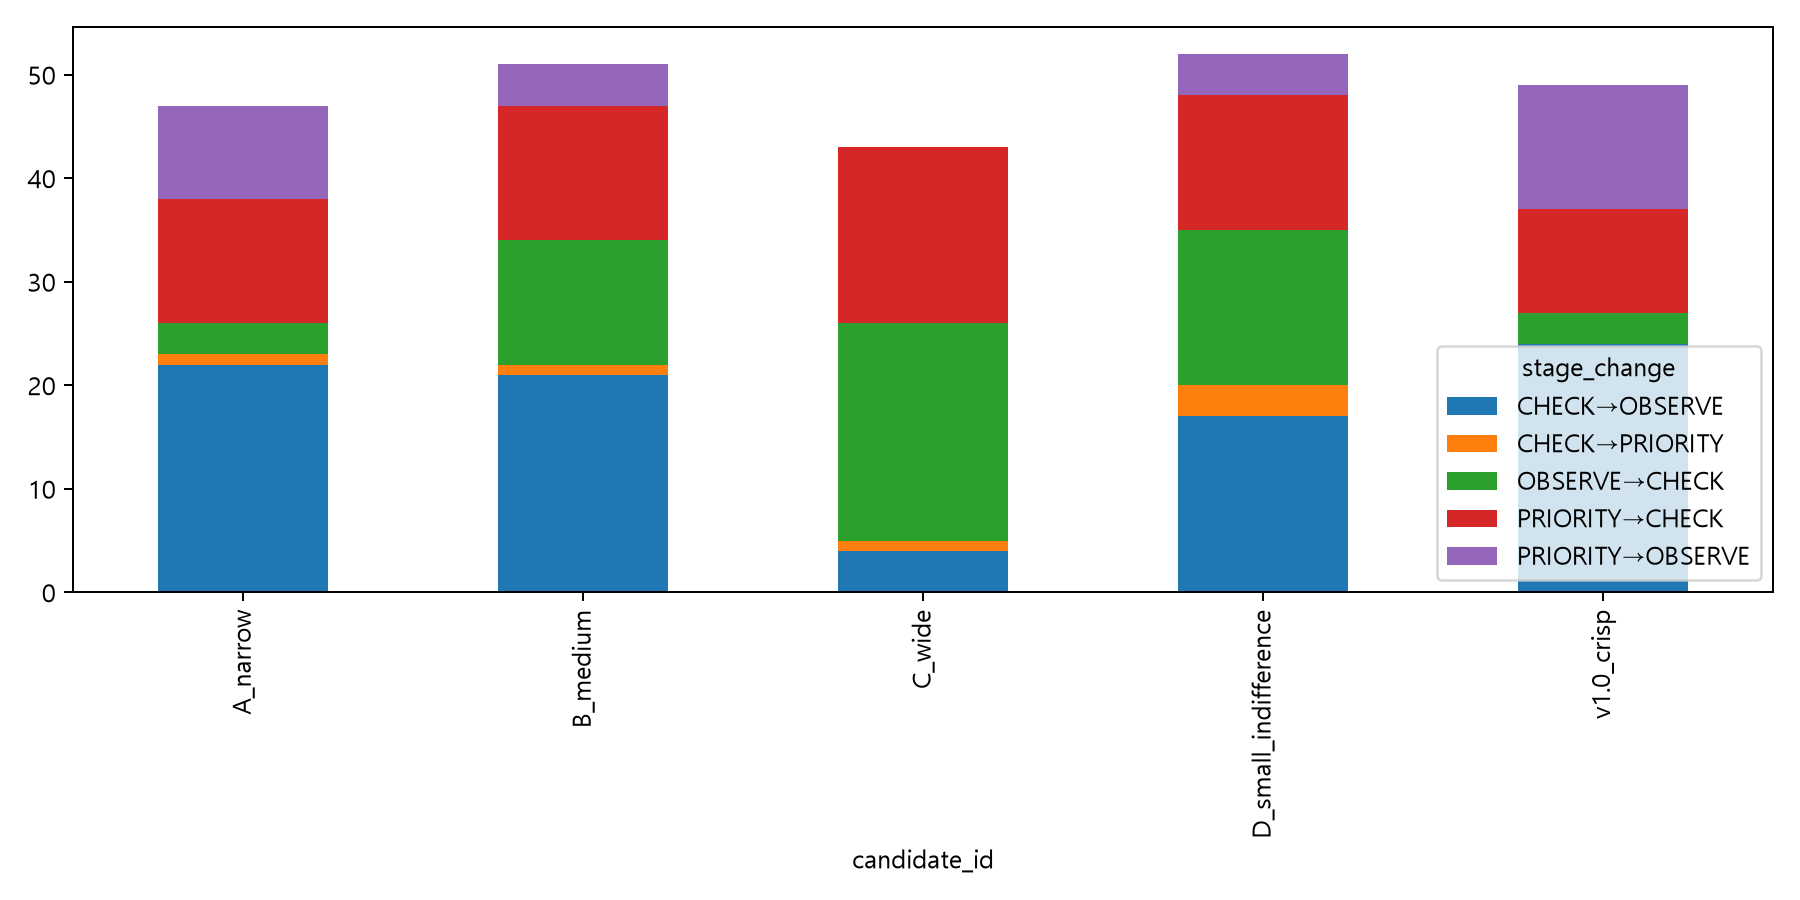

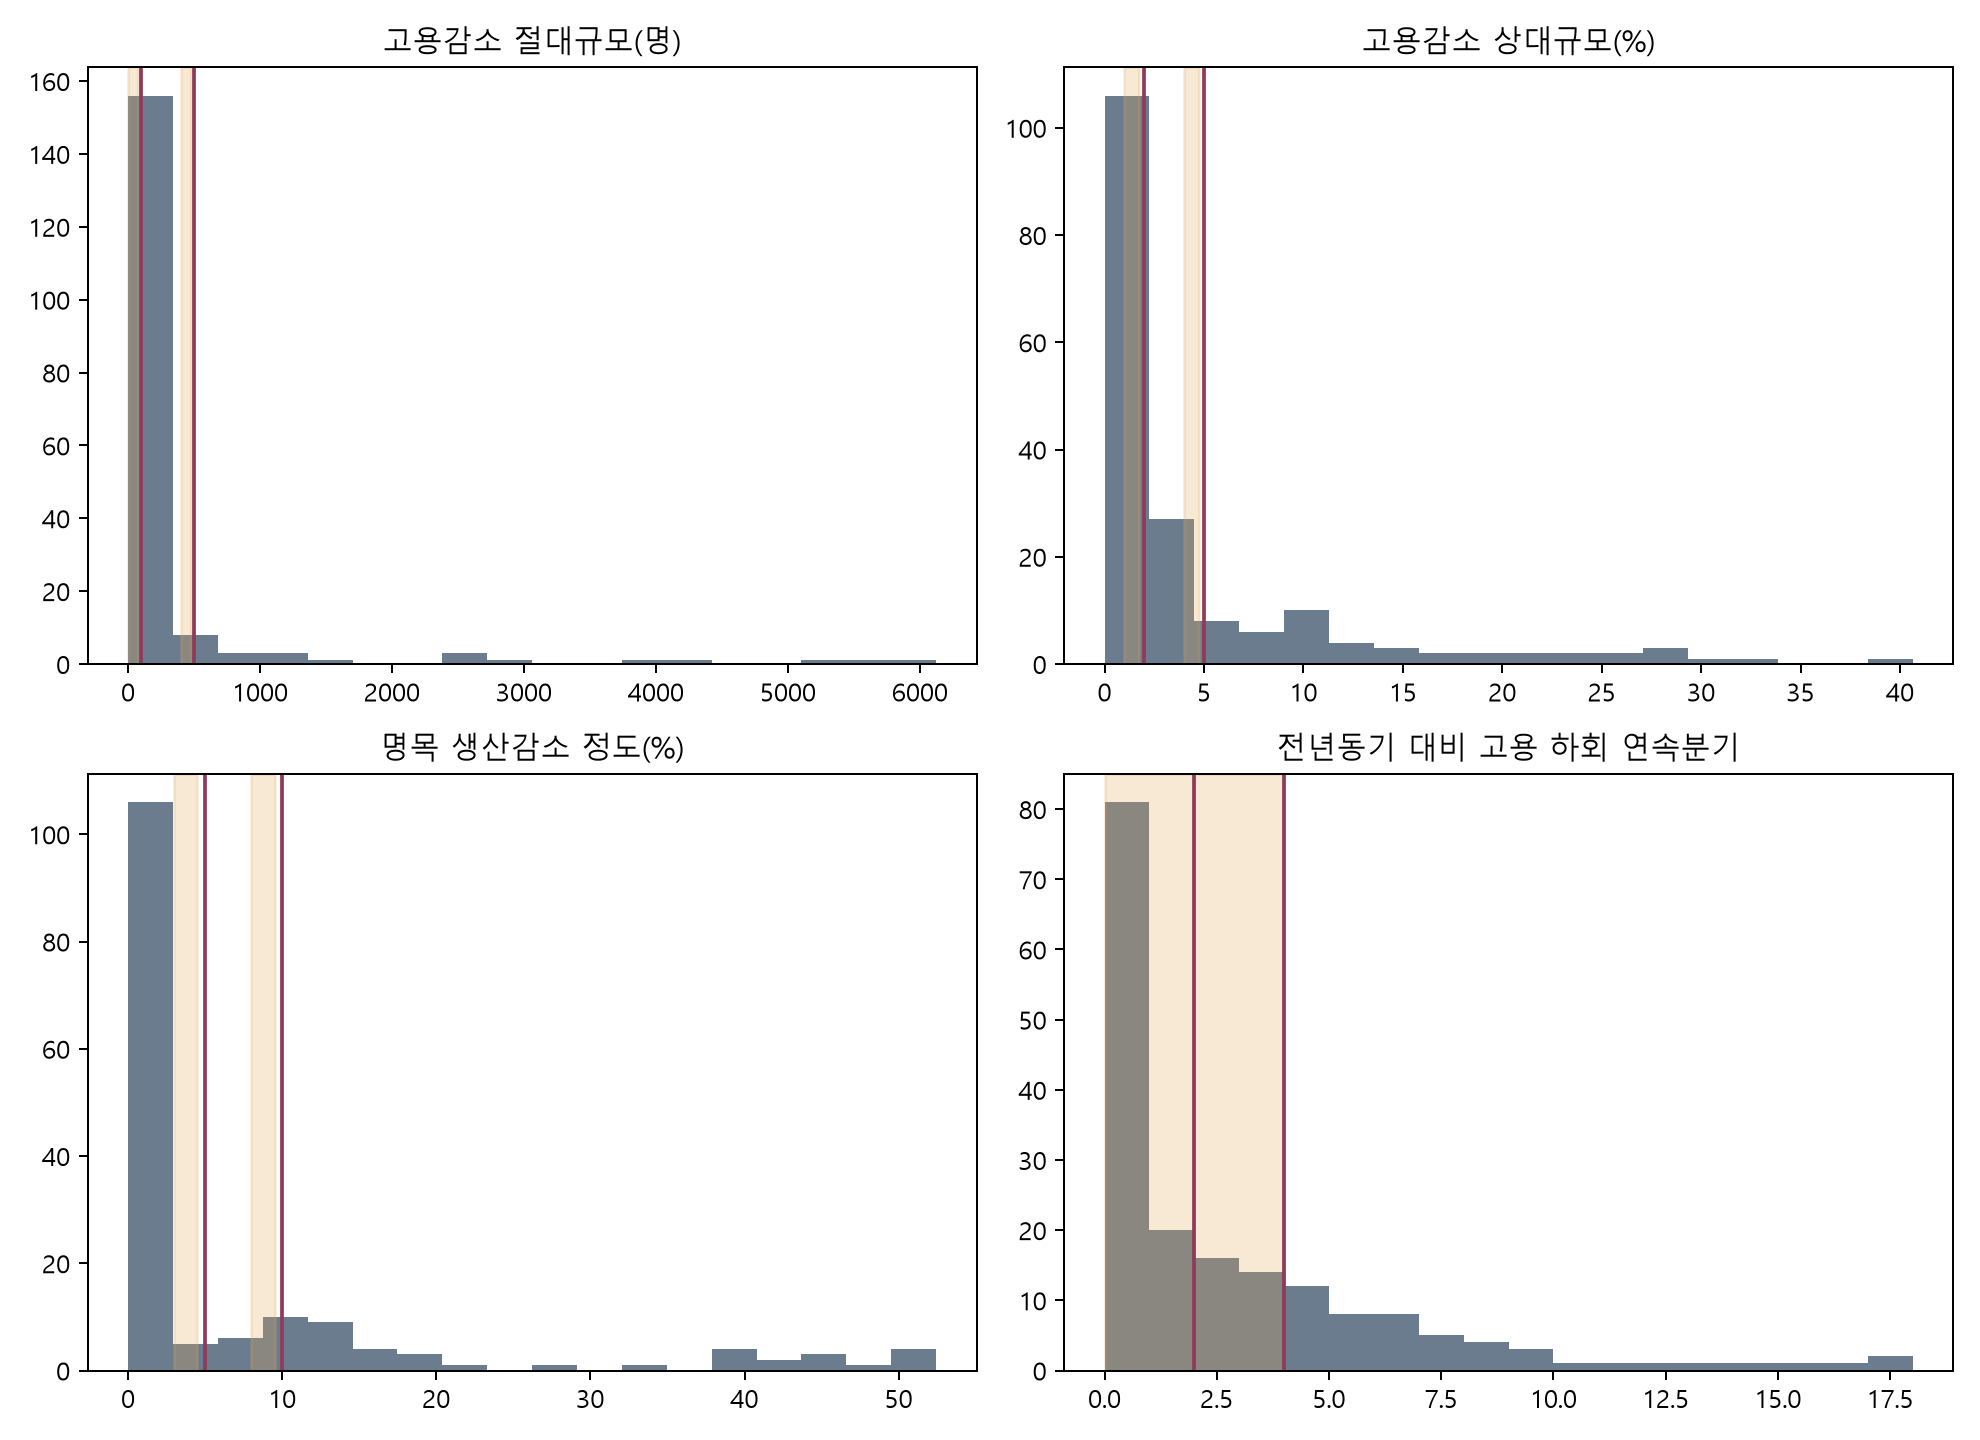

In [5]:
external=table('electre_qp_external_validation')
display(external[external.scenario_id=='기준'])
display(trace[trace.diagnostic_case.astype(bool)][['candidate_id','industry','quarter','boundary','stage','concordance','next_state','state_t2','g1_c','g2_c','g3_c','g4_c','op_rate_used_yoy_pp','firm_count_delta_yoy']])
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_changed_cases.png')))
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_criterion_bands.png')))


## 5. 안정성·업종 제외·시나리오 견고성

,candidate_id,scenario_id,p_factor,n_complete,n_changed,stage_retention_rate,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,v1.0_crisp,기준,0.9,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
1,v1.0_crisp,기준,1.1,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
2,v1.0_crisp,고용중시,0.9,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
3,v1.0_crisp,고용중시,1.1,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
4,v1.0_crisp,지속성중시,0.9,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
5,v1.0_crisp,지속성중시,1.1,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
6,A_narrow,기준,0.9,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
7,A_narrow,기준,1.1,160,0,1.00000,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
8,A_narrow,고용중시,0.9,160,1,0.99375,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
9,A_narrow,고용중시,1.1,160,2,0.98750,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...


,excluded_industry,selected_candidate_id,same_as_full_calibration_selection,selection_uses_holdout,run_id,run_started_at,source_run_id,input_sha256,base_parameter_sha256,candidate_config_sha256,model_spec_version
0,기계,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
1,기타,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
2,목재종이,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
3,비금속,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
4,석유화학,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
5,섬유의복,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
6,운송장비,B_medium,False,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
7,음식료,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
8,전기전자,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...
9,철강,D_small_indifference,True,False,20260916T071935761828Z-c4693433,2026-09-16T07:19:35.761828+00:00,20260916T061849980743Z-d1794cbf,58499908a6af50344a1362c55c840a58cfd80d4373c709...,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...,acabbcc13c428a79a34de3f069923be0d532dba0839246...,changwon-transition-diagnosis-model/1.1.0-cali...


robustness_status
ROBUST                124
ADJACENT_SENSITIVE     32
UNDETERMINED           20
HIGHLY_SENSITIVE        4
Name: count, dtype: int64

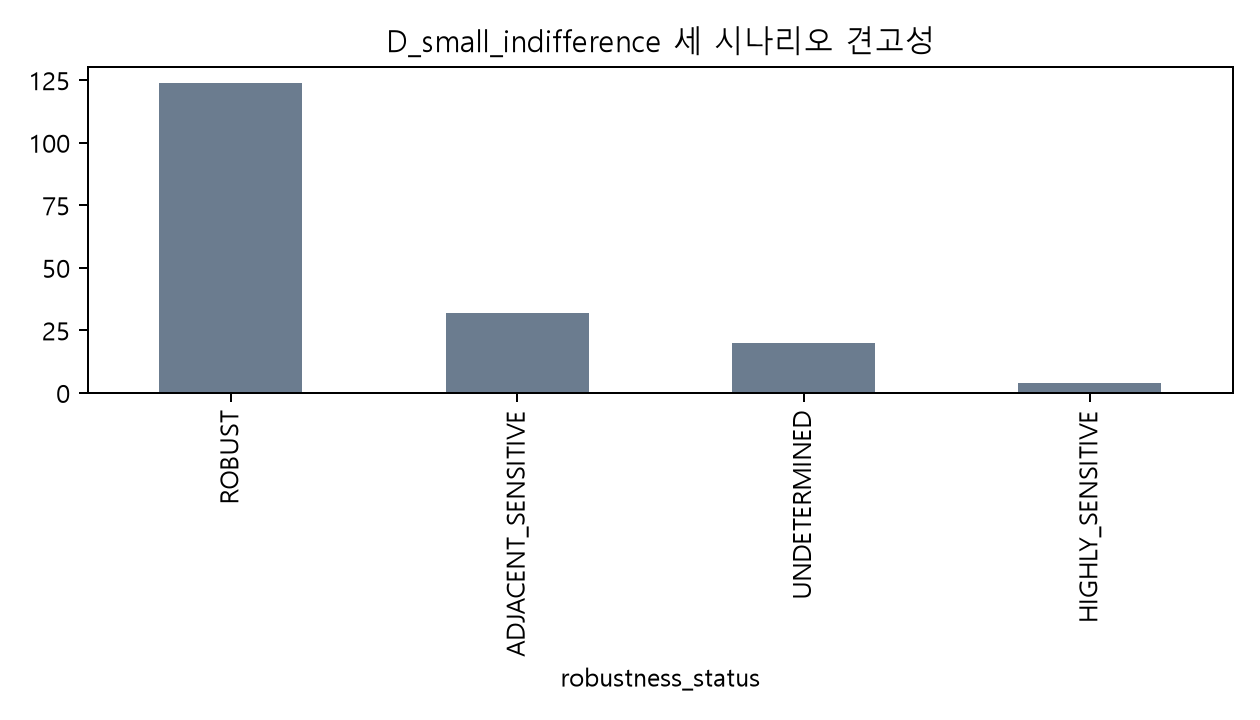

In [6]:
stability=table('electre_qp_parameter_stability')
loio=table('electre_qp_leave_one_industry_out')
robust=table('electre_qp_scenario_robustness')
display(stability)
display(loio)
display(robust.robustness_status.value_counts())
display(Image(filename=str(ROOT/'outputs/figures/electre_qp_scenario_robustness.png')))


## 6. 해석과 결정
보정구간만으로 D Small Indifference Band를 잠정 선택했다. holdout은 선택 후 확인했으며 q·p 후보 재조정에 사용하지 않았다. 일부 지표는 개선됐지만 holdout 단계 순서와 양의 외적 정합성이 충분히 입증되지 않아 최종 판정은 `INSUFFICIENT_EVIDENCE`, 채택 상태는 `NO_QP_CANDIDATE_ADOPTED`다. 데이터는 이후 상태와의 방향적 관계를 보여주지만 원인·정책효과·미래 확률은 입증하지 않는다.